In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("avikpaul4u/vehicle-loan-default-prediction")

print("Path to dataset files:", path)

c:\FraudDetection_Training_Project\fenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\avikpaul4u\vehicle-loan-default-prediction\versions\4


In [3]:
train_path = path + "/train.csv"
test_path = path + "/test.csv"
import pandas as pd
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [4]:
import matplotlib.pyplot as plt
from plotly import tools
import plotly.offline as py
import plotly.figure_factory as ff
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

import seaborn as sns

In [5]:
df = pd.concat([train, test])

In [6]:
print(f"Shape of train: {train.shape}")
print(f"Shape of test: {test.shape}")

Shape of train: (233154, 41)
Shape of test: (112392, 40)


In [7]:
train.shape[0] / test.shape[0]

2.0744714926329277

In [8]:
train.isna().sum()

UNIQUEID                                  0
DISBURSED_AMOUNT                          0
ASSET_COST                                0
LTV                                       0
BRANCH_ID                                 0
SUPPLIER_ID                               0
MANUFACTURER_ID                           0
CURRENT_PINCODE_ID                        0
DATE_OF_BIRTH                             0
EMPLOYMENT_TYPE                        7661
DISBURSAL_DATE                            0
STATE_ID                                  0
EMPLOYEE_CODE_ID                          0
MOBILENO_AVL_FLAG                         0
AADHAR_FLAG                               0
PAN_FLAG                                  0
VOTERID_FLAG                              0
DRIVING_FLAG                              0
PASSPORT_FLAG                             0
PERFORM_CNS_SCORE                         0
PERFORM_CNS_SCORE_DESCRIPTION             0
PRI_NO_OF_ACCTS                           0
PRI_ACTIVE_ACCTS                

In [9]:
train.drop_duplicates(inplace=True)

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UNIQUEID                             233154 non-null  int64  
 1   DISBURSED_AMOUNT                     233154 non-null  int64  
 2   ASSET_COST                           233154 non-null  int64  
 3   LTV                                  233154 non-null  float64
 4   BRANCH_ID                            233154 non-null  int64  
 5   SUPPLIER_ID                          233154 non-null  int64  
 6   MANUFACTURER_ID                      233154 non-null  int64  
 7   CURRENT_PINCODE_ID                   233154 non-null  int64  
 8   DATE_OF_BIRTH                        233154 non-null  object 
 9   EMPLOYMENT_TYPE                      225493 non-null  object 
 10  DISBURSAL_DATE                       233154 non-null  object 
 11  STATE_ID     

In [11]:
data_type = {}
for col in train.columns:
    if train[col].dtype in data_type:
        data_type[train[col].dtype] += 1
    else:
        data_type[train[col].dtype] = 1

data_type

{dtype('int64'): 34, dtype('float64'): 1, dtype('O'): 6}

In [12]:
print(list(train.columns))

['UNIQUEID', 'DISBURSED_AMOUNT', 'ASSET_COST', 'LTV', 'BRANCH_ID', 'SUPPLIER_ID', 'MANUFACTURER_ID', 'CURRENT_PINCODE_ID', 'DATE_OF_BIRTH', 'EMPLOYMENT_TYPE', 'DISBURSAL_DATE', 'STATE_ID', 'EMPLOYEE_CODE_ID', 'MOBILENO_AVL_FLAG', 'AADHAR_FLAG', 'PAN_FLAG', 'VOTERID_FLAG', 'DRIVING_FLAG', 'PASSPORT_FLAG', 'PERFORM_CNS_SCORE', 'PERFORM_CNS_SCORE_DESCRIPTION', 'PRI_NO_OF_ACCTS', 'PRI_ACTIVE_ACCTS', 'PRI_OVERDUE_ACCTS', 'PRI_CURRENT_BALANCE', 'PRI_SANCTIONED_AMOUNT', 'PRI_DISBURSED_AMOUNT', 'SEC_NO_OF_ACCTS', 'SEC_ACTIVE_ACCTS', 'SEC_OVERDUE_ACCTS', 'SEC_CURRENT_BALANCE', 'SEC_SANCTIONED_AMOUNT', 'SEC_DISBURSED_AMOUNT', 'PRIMARY_INSTAL_AMT', 'SEC_INSTAL_AMT', 'NEW_ACCTS_IN_LAST_SIX_MONTHS', 'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS', 'AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH', 'NO_OF_INQUIRIES', 'LOAN_DEFAULT']


In [13]:
object_cols = []
for col in train.columns:
    if train[col].dtype == 'object':
        object_cols.append(col)

object_cols

['DATE_OF_BIRTH',
 'EMPLOYMENT_TYPE',
 'DISBURSAL_DATE',
 'PERFORM_CNS_SCORE_DESCRIPTION',
 'AVERAGE_ACCT_AGE',
 'CREDIT_HISTORY_LENGTH']

In [14]:
train['PERFORM_CNS_SCORE_DESCRIPTION'].value_counts()

PERFORM_CNS_SCORE_DESCRIPTION
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk                                                  3748
Not Scored: Not Enough Info available on the c

In [15]:
train['EMPLOYMENT_TYPE'].value_counts()

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Name: count, dtype: int64

In [16]:
train['CREDIT_HISTORY_LENGTH'].value_counts()

CREDIT_HISTORY_LENGTH
0yrs 0mon      119127
0yrs 6mon        4761
2yrs 1mon        4745
0yrs 7mon        4017
2yrs 0mon        3833
                ...  
23yrs 4mon          1
25yrs 11mon         1
23yrs 1mon          1
21yrs 2mon          1
22yrs 10mon         1
Name: count, Length: 294, dtype: int64

In [17]:
train.groupby('LOAN_DEFAULT')['UNIQUEID'].count()

LOAN_DEFAULT
0    182543
1     50611
Name: UNIQUEID, dtype: int64

In [18]:
train.EMPLOYMENT_TYPE.fillna('Missing', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_3360\2217623196.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [19]:
train.EMPLOYMENT_TYPE.value_counts()

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Missing            7661
Name: count, dtype: int64

In [20]:
train.isna().sum()

UNIQUEID                               0
DISBURSED_AMOUNT                       0
ASSET_COST                             0
LTV                                    0
BRANCH_ID                              0
SUPPLIER_ID                            0
MANUFACTURER_ID                        0
CURRENT_PINCODE_ID                     0
DATE_OF_BIRTH                          0
EMPLOYMENT_TYPE                        0
DISBURSAL_DATE                         0
STATE_ID                               0
EMPLOYEE_CODE_ID                       0
MOBILENO_AVL_FLAG                      0
AADHAR_FLAG                            0
PAN_FLAG                               0
VOTERID_FLAG                           0
DRIVING_FLAG                           0
PASSPORT_FLAG                          0
PERFORM_CNS_SCORE                      0
PERFORM_CNS_SCORE_DESCRIPTION          0
PRI_NO_OF_ACCTS                        0
PRI_ACTIVE_ACCTS                       0
PRI_OVERDUE_ACCTS                      0
PRI_CURRENT_BALA

In [21]:
train['CREDIT_HISTORY_LENGTH'].value_counts()

CREDIT_HISTORY_LENGTH
0yrs 0mon      119127
0yrs 6mon        4761
2yrs 1mon        4745
0yrs 7mon        4017
2yrs 0mon        3833
                ...  
23yrs 4mon          1
25yrs 11mon         1
23yrs 1mon          1
21yrs 2mon          1
22yrs 10mon         1
Name: count, Length: 294, dtype: int64

In [22]:
date_cols = ['DATE_OF_BIRTH', 'DISBURSAL_DATE']

In [23]:
duration_cols = ['AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH']

In [25]:
train[duration_cols]

,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH
0,0yrs 0mon,0yrs 0mon
1,1yrs 11mon,1yrs 11mon
2,0yrs 0mon,0yrs 0mon
3,0yrs 8mon,1yrs 3mon
4,0yrs 0mon,0yrs 0mon
...,...,...
233149,1yrs 9mon,3yrs 3mon
233150,0yrs 6mon,0yrs 6mon
233151,0yrs 0mon,0yrs 0mon
233152,0yrs 0mon,0yrs 0mon


In [36]:
train

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-1985,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-1993,Self employed,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-1977,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,626432,63213,105405,60.72,34,20700,48,1050,01-08-1988,Salaried,...,0,0,4084,0,0,0,1yrs 9mon,3yrs 3mon,0,0
233150,606141,73651,100600,74.95,34,23775,51,990,05-12-1988,Self employed,...,0,0,1565,0,0,0,0yrs 6mon,0yrs 6mon,0,0
233151,613658,33484,71212,48.45,77,22186,86,2299,01-06-1976,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
233152,548084,34259,73286,49.10,77,22186,86,2299,26-03-1994,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


In [56]:
def parse_duration(duration):
    _y, _m = (duration).split(" ")
    duration_in_months = int(_y.split("yrs")[0])*12 + int(_m.split("mon")[0])

    return duration_in_months

In [ ]:
for col in duration_cols:
    train[col] = train[col].apply(lambda x: parse_duration(x))

    # test[col] = test[col].apply(lambda x: parse_duration(x))

AttributeError: 'int' object has no attribute 'split'

In [57]:
_train = train['AVERAGE_ACCT_AGE'].apply(parse_duration)

In [27]:
train.groupby('PERFORM_CNS_SCORE_DESCRIPTION')['LOAN_DEFAULT'].count()

PERFORM_CNS_SCORE_DESCRIPTION
A-Very Low Risk                                             14124
B-Very Low Risk                                              9201
C-Very Low Risk                                             16045
D-Very Low Risk                                             11358
E-Low Risk                                                   5821
F-Low Risk                                                   8485
G-Low Risk                                                   3988
H-Medium Risk                                                6855
I-Medium Risk                                                5557
J-High Risk                                                  3748
K-High Risk                                                  8277
L-Very High Risk                                             1134
M-Very High Risk                                             8776
No Bureau History Available                                116950
Not Scored: More than 50 active Accounts found

In [28]:
g = train.groupby("PERFORM_CNS_SCORE_DESCRIPTION")['LOAN_DEFAULT']
gg = pd.concat([g.value_counts(), 
                g.value_counts(normalize=True).mul(100)],axis=1, keys=('counts','percentage'))
print (gg)

                                                                 counts  \
PERFORM_CNS_SCORE_DESCRIPTION                      LOAN_DEFAULT           
A-Very Low Risk                                    0              11783   
                                                   1               2341   
B-Very Low Risk                                    0               7993   
                                                   1               1208   
C-Very Low Risk                                    0              13275   
                                                   1               2770   
D-Very Low Risk                                    0               9659   
                                                   1               1699   
E-Low Risk                                         0               4821   
                                                   1               1000   
F-Low Risk                                         0               6905   
                         

count    233154.000000
mean      54356.993528
std       12971.314171
min       13320.000000
25%       47145.000000
50%       53803.000000
75%       60413.000000
max      990572.000000
Name: DISBURSED_AMOUNT, dtype: float64


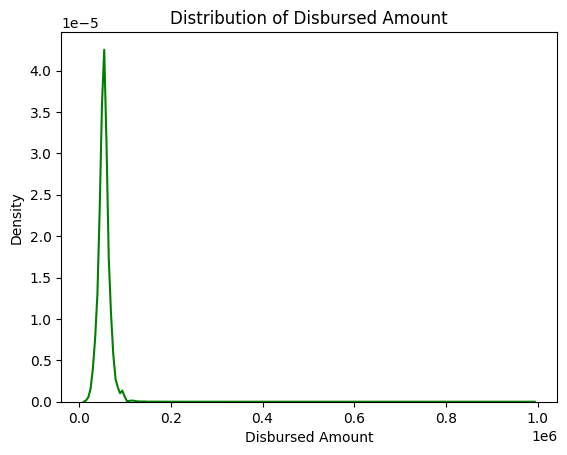

In [29]:
print(train.DISBURSED_AMOUNT.describe())
# plot_distribution('DISBURSED_AMOUNT','green')
sns.kdeplot(train.DISBURSED_AMOUNT, color='green')
plt.title('Distribution of Disbursed Amount')
plt.xlabel('Disbursed Amount')
plt.ylabel('Density')
plt.show()

### Outlier detection

In [30]:
# Outlier detection


In [ ]:
# import torch
# _tensor = torch.tensor([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]])
# print(torch.nn.functional.softmax(_tensor, dim=-1))

tensor([[0.3006, 0.3322, 0.3672],
        [0.3006, 0.3322, 0.3672]])


In [ ]:
# import torch
# def compute_map(eval_preds):
#     labels, logits = eval_preds

#     probs = torch.nn.functional.softmax(logits, dim=-1)